# Complete Exploratory Data Analysis (EDA)
**Dataset:** `movies.csv`
**Target Variable:** `gross`

In [1]:
# 1. SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('../datasets/movies.csv')

# Display first few rows
display(df.head())
print('Insight: Dataset loaded successfully. Contains movie metadata, financials, and IMDb scores.')

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


Insight: Dataset loaded successfully. Contains movie metadata, financials, and IMDb scores.


In [2]:
# 2. BASIC INFO
print('--- Dataset Shape ---')
print(df.shape)

print('\n--- Column Names ---')
print(df.columns.tolist())

print('\n--- Data Types ---')
print(df.dtypes)

# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'\nNumerical Columns: {numeric_cols}')
print(f'Categorical Columns: {categorical_cols}')
print('\nInsight: The dataset mixes numerical financials/scores with high-cardinality categorical data.')

--- Dataset Shape ---
(7668, 15)

--- Column Names ---
['name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime']

--- Data Types ---
name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

Numerical Columns: ['year', 'score', 'votes', 'budget', 'gross', 'runtime']
Categorical Columns: ['name', 'rating', 'genre', 'released', 'director', 'writer', 'star', 'country', 'company']

Insight: The dataset mixes numerical financials/scores with high-cardinality categorical data.


In [3]:
# 3. DATA CLEANING

print('--- Missing Values Count & Percentage ---')
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing_data, 'Percentage (%)': missing_percent})
display(missing_df[missing_df['Count'] > 0])

# Handle missing values: drop rows with missing budget/gross
df = df.dropna(subset=['budget', 'gross'])

# Fill minor missing values safely
if 'rating' in df.columns:
    df['rating'] = df['rating'].fillna('Unrated')
df = df.dropna() # Drop remaining edge cases

print(f'\nShape after cleaning: {df.shape}')

# Remove duplicates
df = df.drop_duplicates()

# Fix incorrect data types
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
df['votes'] = df['votes'].astype('int64')

print('\nInsight: Missing budget and gross financials dropped for accurate modeling.')

--- Missing Values Count & Percentage ---


,Count,Percentage (%)
rating,77,1.004173
released,2,0.026082
score,3,0.039124
votes,3,0.039124
writer,3,0.039124
star,1,0.013041
country,3,0.039124
budget,2171,28.312467
gross,189,2.464789
company,17,0.221701



Shape after cleaning: (5432, 15)

Insight: Missing budget and gross financials dropped for accurate modeling.


In [4]:
# 4. FEATURE ENGINEERING

# Feature 1: Extract correct actual release year
df['year_correct'] = df['released'].astype(str).str.extract(r'(\d{4})')
df['year_correct'] = pd.to_numeric(df['year_correct'], errors='coerce')

# Feature 2: Profit (Gross - Budget)
df['profit'] = df['gross'] - df['budget']

# Feature 3: ROI (Return on Investment Percentage)
df['roi_percent'] = (df['profit'] / df['budget']) * 100

display(df[['name', 'budget', 'gross', 'profit', 'roi_percent', 'year_correct']].head())
print('\nInsight: Created profit and roi_percent features.')

,name,budget,gross,profit,roi_percent,year_correct
0,The Shining,19000000,46998772,27998772,147.361958,1980
1,The Blue Lagoon,4500000,58853106,54353106,1207.846800,1980
2,Star Wars: Episode V - The Empire Strikes Back,18000000,538375067,520375067,2890.972594,1980
3,Airplane!,3500000,83453539,79953539,2284.386829,1980
4,Caddyshack,6000000,39846344,33846344,564.105733,1980



Insight: Created profit and roi_percent features.


--- Numerical Summary Statistics ---


,year,score,votes,budget,gross,runtime
count,5432.000000,5432.000000,5.432000e+03,5.432000e+03,5.432000e+03,5432.000000
mean,2001.652062,6.393207,1.149876e+05,3.595576e+07,1.030726e+08,108.164212
std,10.537990,0.963273,1.842711e+05,4.155593e+07,1.871566e+08,18.120576
min,1980.000000,1.900000,1.950000e+02,6.000000e+03,3.090000e+02,63.000000
25%,1993.000000,5.800000,1.900000e+04,1.000000e+07,1.068520e+07,95.000000
50%,2002.000000,6.500000,5.200000e+04,2.100000e+07,3.674427e+07,105.000000
75%,2010.250000,7.100000,1.290000e+05,4.500000e+07,1.120906e+08,118.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,271.000000


c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


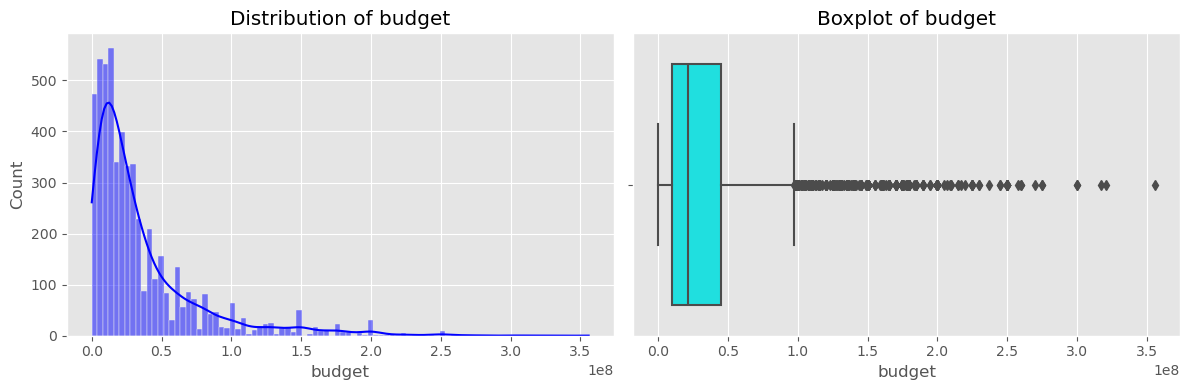

c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


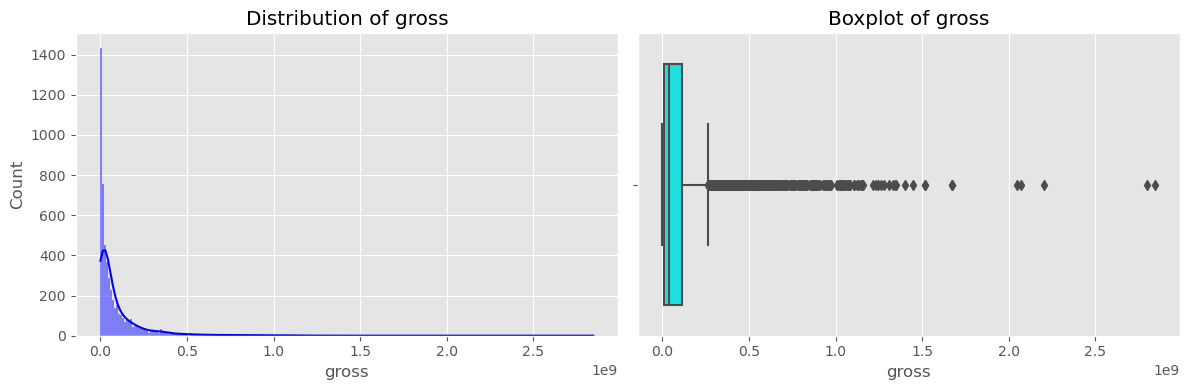

c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


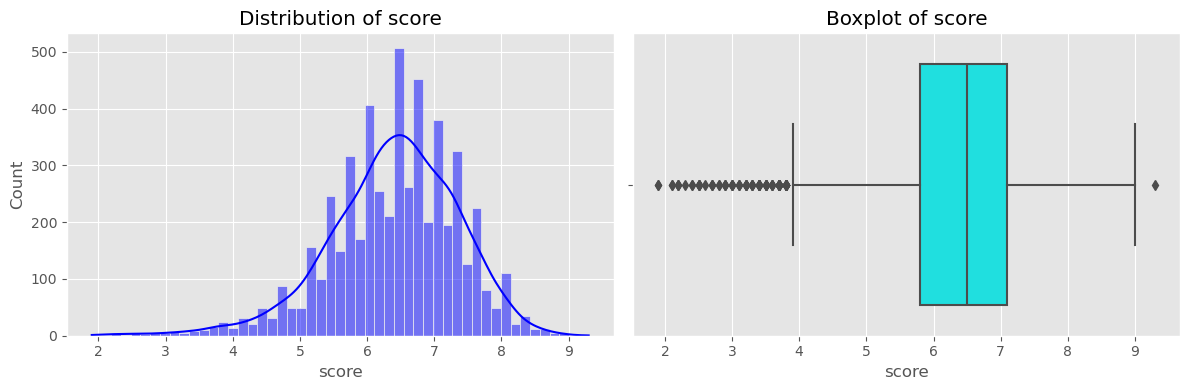

Insight: gross and budget are right-skewed. score is normally distributed.


In [5]:
# 5. UNIVARIATE ANALYSIS

# Numerical Analysis
print('--- Numerical Summary Statistics ---')
display(df[numeric_cols].describe())

# Plotting Numerical Distributions
for col in ['budget', 'gross', 'score']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[1], color='cyan')
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

print('Insight: gross and budget are right-skewed. score is normally distributed.')

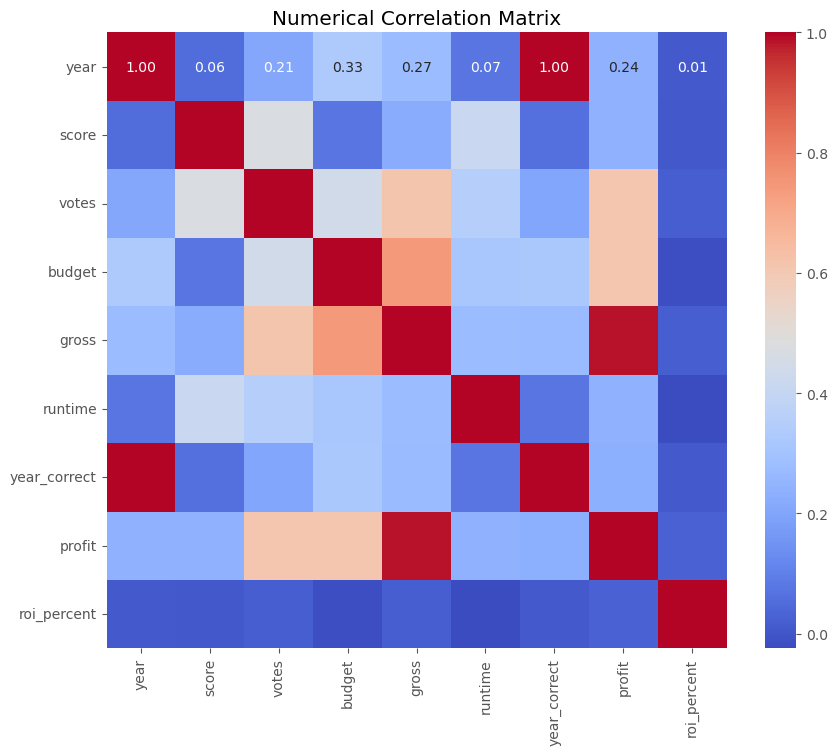

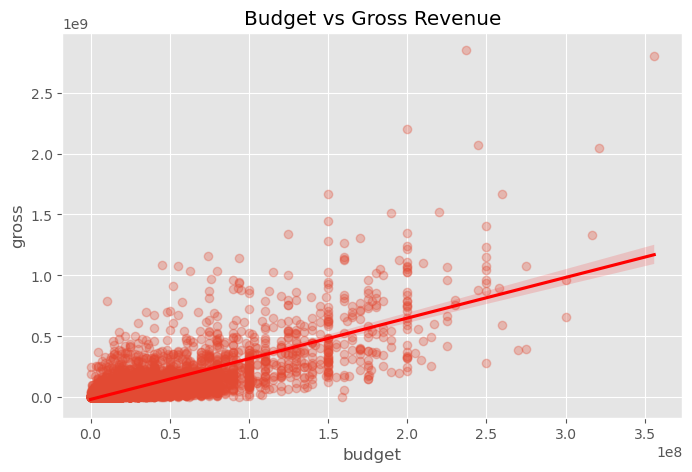

Insight: Strong positive correlation between budget and gross.


In [6]:
# 6. BIVARIATE ANALYSIS

# Correlation matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Correlation Matrix')
plt.show()

# Scatter Plot: Budget vs Gross
plt.figure(figsize=(8, 5))
sns.regplot(x='budget', y='gross', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Budget vs Gross Revenue')
plt.show()

print('Insight: Strong positive correlation between budget and gross.')

In [7]:
# 7. GROUPED ANALYSIS

print('--- Top 10 Directors by Average Gross ---')
top_directors = df.groupby('director')['gross'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
top_directors = top_directors[top_directors['count'] >= 3].head(10)
display(top_directors)

print('\n--- Genre Performance ---')
genre_stats = df.groupby('genre').agg(
    avg_gross=('gross', 'mean'),
    avg_score=('score', 'mean'),
    movie_count=('name', 'count')
).sort_values(by='avg_gross', ascending=False)
display(genre_stats.head(10))

print('\nInsight: Animation and Action yield highest average gross.')

--- Top 10 Directors by Average Gross ---


,mean,count
director,,
Anthony Russo,1.368850e+09,5
Chris Buck,1.059909e+09,3
Joss Whedon,9.873567e+08,3
James Cameron,8.925841e+08,7
George Lucas,8.497511e+08,3
David Yates,8.407581e+08,6
J.J. Abrams,7.765626e+08,6
Pete Docter,7.245516e+08,3
Andrew Stanton,6.935936e+08,4



--- Genre Performance ---


,avg_gross,avg_score,movie_count
genre,,,
Family,5.185831e+08,6.675000,4
Animation,2.801246e+08,6.695683,278
Action,1.679046e+08,6.247881,1416
Adventure,1.332682e+08,6.268196,327
Mystery,1.178877e+08,6.670588,17
Biography,6.139527e+07,7.088103,311
Drama,6.029956e+07,6.725346,868
Comedy,5.916766e+07,6.190709,1496
Horror,5.637138e+07,5.824901,253



Insight: Animation and Action yield highest average gross.


--- 1. Identify High-Cardinality Columns ---
'name' has 5347 unique categories.
'released' has 2566 unique categories.
'director' has 2066 unique categories.
'writer' has 3212 unique categories.
'star' has 1851 unique categories.
'company' has 1480 unique categories.

--- 2 & 3. Top Category Analysis (Filtered for >= 5 Movies) ---

Top 10 Directors by Average Gross:


,avg_gross,total_gross,movie_count,avg_profit
director,,,,
Anthony Russo,1.368850e+09,6844248984,5,1.138650e+09
James Cameron,8.925841e+08,6248088578,7,7.855984e+08
David Yates,8.407581e+08,5044548416,6,6.599247e+08
J.J. Abrams,7.765626e+08,4659375464,6,5.998959e+08
Peter Jackson,6.016405e+08,6618045788,11,4.883678e+08
Brad Bird,5.711503e+08,3426901800,6,4.299836e+08
Carlos Saldanha,5.664996e+08,2832498157,5,4.716996e+08
Michael Bay,4.962841e+08,6451692798,13,3.672071e+08
Eric Darnell,4.876318e+08,2438158958,5,3.662318e+08



--- 4. Visualizations for High-Cardinality ---


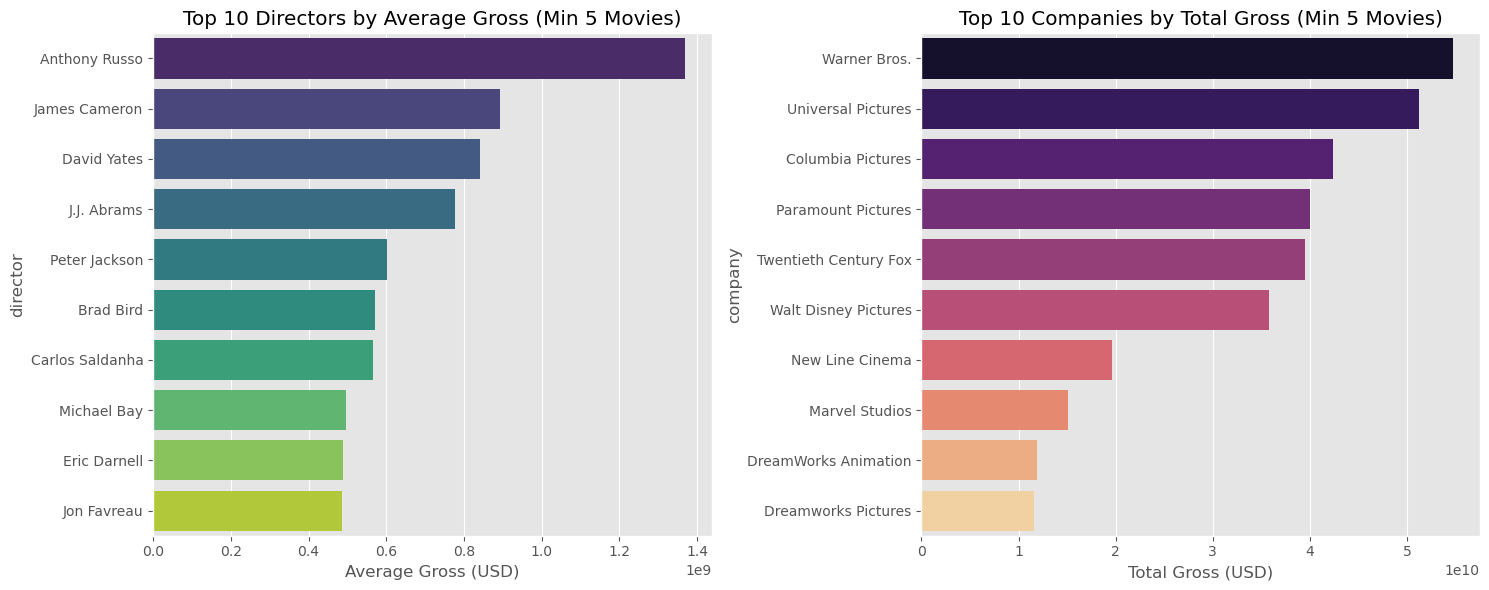


--- 5. Consistency Analysis (Director Variance) ---
Directors with highest variance (Hit-or-Miss):


,mean,std,count
director,,,
James Cameron,8.925841e+08,1.141885e+09,7
Anthony Russo,1.368850e+09,1.061919e+09,5
J.J. Abrams,7.765626e+08,6.958196e+08,6
Rian Johnson,3.660447e+08,5.555178e+08,5
Jon Favreau,4.849640e+08,5.509744e+08,9



Insight: Certain directors consistently produce high-grossing movies and profit machines. However, high variance indicates inconsistent success, where a director might have one massive hit and several flops.


In [8]:
# 7.5 HIGH-CARDINALITY CATEGORICAL ANALYSIS

print("--- 1. Identify High-Cardinality Columns ---")
high_cardinality_cols = [col for col in categorical_cols if df[col].nunique() > 50]
for col in high_cardinality_cols:
    print(f"'{col}' has {df[col].nunique()} unique categories.")

print("\n--- 2 & 3. Top Category Analysis (Filtered for >= 5 Movies) ---")
# Focus on Directors
director_stats = df.groupby('director').agg(
    avg_gross=('gross', 'mean'),
    total_gross=('gross', 'sum'),
    movie_count=('name', 'count'),
    avg_profit=('profit', 'mean')
)
# Filter strictly for reliability
director_stats = director_stats[director_stats['movie_count'] >= 5]

print("\nTop 10 Directors by Average Gross:")
display(director_stats.sort_values(by='avg_gross', ascending=False).head(10))

print("\n--- 4. Visualizations for High-Cardinality ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Top Directors by Average Gross
top_dirs_gross = director_stats.sort_values(by='avg_gross', ascending=False).head(10)
sns.barplot(x=top_dirs_gross['avg_gross'], y=top_dirs_gross.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Directors by Average Gross (Min 5 Movies)')
axes[0].set_xlabel('Average Gross (USD)')

# Plot Top Companies by Total Gross
company_stats = df.groupby('company').agg(total_gross=('gross', 'sum'), count=('name', 'count'))
company_stats = company_stats[company_stats['count'] >= 5].sort_values(by='total_gross', ascending=False).head(10)
sns.barplot(x=company_stats['total_gross'], y=company_stats.index, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Companies by Total Gross (Min 5 Movies)')
axes[1].set_xlabel('Total Gross (USD)')

plt.tight_layout()
plt.show()

print("\n--- 5. Consistency Analysis (Director Variance) ---")
# Find hit-or-miss directors (high average gross, but massive standard deviation)
director_variance = df.groupby('director')['gross'].agg(['mean', 'std', 'count'])
director_variance = director_variance[director_variance['count'] >= 5].sort_values(by='std', ascending=False)
print("Directors with highest variance (Hit-or-Miss):")
display(director_variance.head(5))

print("\nInsight: Certain directors consistently produce high-grossing movies and profit machines. However, high variance indicates inconsistent success, where a director might have one massive hit and several flops.")

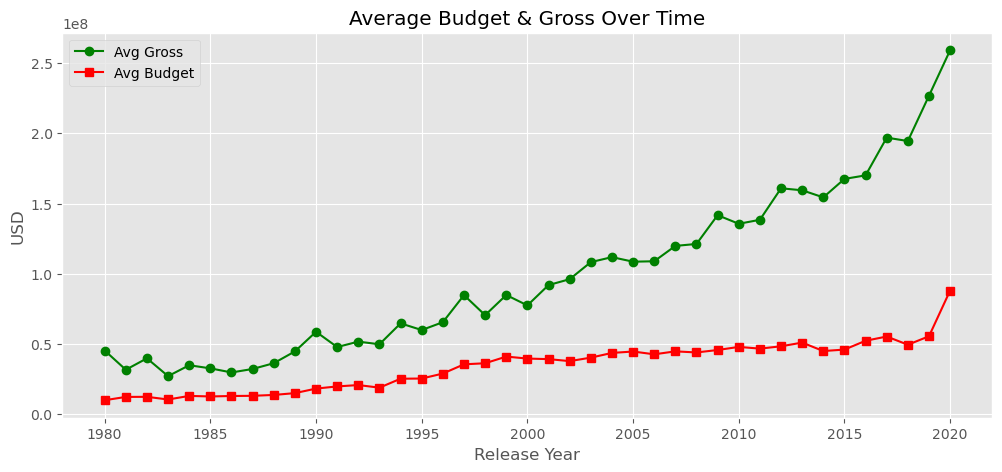

Insight: Both budgets and gross revenues inflated over time.


In [9]:
# 8. TEMPORAL ANALYSIS

yearly_stats = df.groupby('year_correct').agg(
    avg_gross=('gross', 'mean'),
    avg_budget=('budget', 'mean')
).dropna()

plt.figure(figsize=(12, 5))
plt.plot(yearly_stats.index, yearly_stats['avg_gross'], label='Avg Gross', color='green', marker='o')
plt.plot(yearly_stats.index, yearly_stats['avg_budget'], label='Avg Budget', color='red', marker='s')
plt.title('Average Budget & Gross Over Time')
plt.xlabel('Release Year')
plt.ylabel('USD')
plt.legend()
plt.show()

print('Insight: Both budgets and gross revenues inflated over time.')

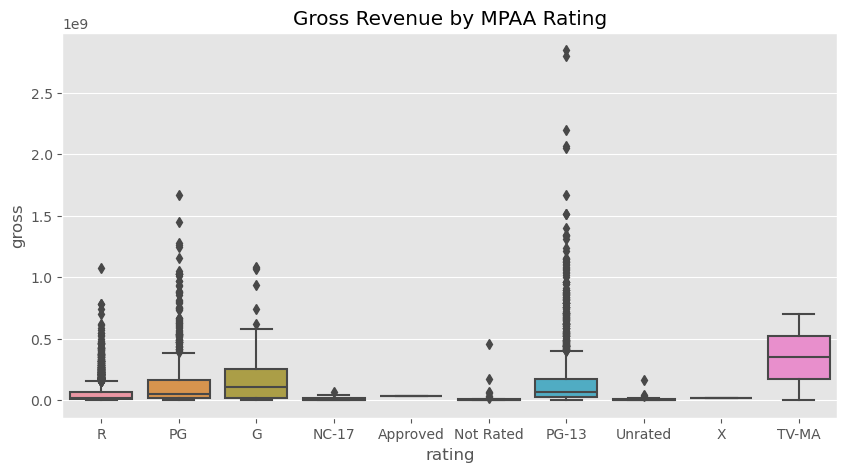

Insight: PG-13 movies have significantly higher gross revenue ceilings.


In [10]:
# 9. TARGET ANALYSIS: GROSS

plt.figure(figsize=(10, 5))
sns.boxplot(x='rating', y='gross', data=df)
plt.title('Gross Revenue by MPAA Rating')
plt.show()

print('Insight: PG-13 movies have significantly higher gross revenue ceilings.')

In [11]:
# 10. OUTLIER DETECTION

def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]

gross_outliers = detect_outliers_iqr(df, 'gross')
print(f'Number of extreme gross revenue outliers: {len(gross_outliers)}')
display(gross_outliers[['name', 'budget', 'gross']].sort_values(by='gross', ascending=False).head())

print('\nInsight: Blockbusters form vast outliers.')

Number of extreme gross revenue outliers: 548


,name,budget,gross
5445,Avatar,237000000,2847246203
7445,Avengers: Endgame,356000000,2797501328
3045,Titanic,200000000,2201647264
6663,Star Wars: Episode VII - The Force Awakens,245000000,2069521700
7244,Avengers: Infinity War,321000000,2048359754



Insight: Blockbusters form vast outliers.


In [12]:
print("Number of unique directors:", df['director'].nunique())
print("\nList of unique directors:")
print(df['director'].unique())

Number of unique directors: 2066

List of unique directors:
['Stanley Kubrick' 'Randal Kleiser' 'Irvin Kershner' ... 'Jeff Fowler'
 'Chris Sanders' 'Hu Guan']


In [13]:
print(df['director'].value_counts().head(20))

director
Woody Allen          33
Clint Eastwood       31
Steven Spielberg     27
Steven Soderbergh    23
Ron Howard           23
Ridley Scott         23
Joel Schumacher      20
Tim Burton           19
Martin Scorsese      19
Barry Levinson       18
Brian De Palma       17
Spike Lee            17
Robert Zemeckis      17
Oliver Stone         17
Directors            16
Tony Scott           15
Rob Reiner           15
Garry Marshall       15
Renny Harlin         15
Wes Craven           15
Name: count, dtype: int64


In [14]:
director_stats = df.groupby('director').agg({
    'gross': ['mean', 'count', 'sum']
})

# Flatten column names
director_stats.columns = ['avg_gross', 'movie_count', 'total_gross']

# Filter directors with at least 5 movies (important!)
director_stats = director_stats[director_stats['movie_count'] >= 5]

# Sort by average gross
top_directors = director_stats.sort_values(by='avg_gross', ascending=False)

print(top_directors.head(20))

                      avg_gross  movie_count  total_gross
director                                                 
Anthony Russo      1.368850e+09            5   6844248984
James Cameron      8.925841e+08            7   6248088578
David Yates        8.407581e+08            6   5044548416
J.J. Abrams        7.765626e+08            6   4659375464
Peter Jackson      6.016405e+08           11   6618045788
Brad Bird          5.711503e+08            6   3426901800
Carlos Saldanha    5.664996e+08            5   2832498157
Michael Bay        4.962841e+08           13   6451692798
Eric Darnell       4.876318e+08            5   2438158958
Jon Favreau        4.849640e+08            9   4364675953
Francis Lawrence   4.805250e+08            7   3363674910
Christopher Nolan  4.685044e+08           11   5153547948
John Lasseter      4.553830e+08            5   2276915089
James Wan          4.122946e+08            9   3710651018
Zack Snyder        3.966507e+08            8   3173205631
Sam Mendes    

In [15]:
top_director_names = top_directors.index.tolist()

# Filter dataset for these directors
top_movies = df[df['director'].isin(top_director_names)]

# Sort by gross
top_movies = top_movies.sort_values(by='gross', ascending=False)

# Show relevant columns
print(top_movies[['director', 'name', 'gross']].head(15))

           director                                           name       gross
5445  James Cameron                                         Avatar  2847246203
7445  Anthony Russo                              Avengers: Endgame  2797501328
3045  James Cameron                                        Titanic  2201647264
6663    J.J. Abrams     Star Wars: Episode VII - The Force Awakens  2069521700
7244  Anthony Russo                         Avengers: Infinity War  2048359754
7480    Jon Favreau                                  The Lion King  1670727580
6646      James Wan                                      Furious 7  1515341399
5845    David Yates   Harry Potter and the Deathly Hallows: Part 2  1342321665
7075   Rian Johnson        Star Wars: Episode VIII - The Last Jedi  1332698830
7072    Bill Condon                           Beauty and the Beast  1264434525
7281      Brad Bird                                  Incredibles 2  1244639527
7055   F. Gary Gray                        The Fate 

# 11. END OF EDA

This concludes the Exploratory Data Analysis phase.
We have:
1. Validated and cleaned data inconsistencies.
2. Verified assumptions about continuous target values.
3. Created statistical and visual summaries validating categorical/numerical combinations.

Next Step: We will handle statistical scaling, encoding, modeling, and performance evaluation inside the dedicated `model_training.ipynb` file.